# Import modules and load datasets

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
players = pd.read_csv("WorldCupPlayers.csv")
matches = pd.read_csv("WorldCupMatches.csv")
world_cup = pd.read_csv("WorldCups.csv")

In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    object 
 2   Stage                 852 non-null    object 
 3   Stadium               852 non-null    object 
 4   City                  852 non-null    object 
 5   Home Team Name        852 non-null    object 
 6   Home Team Goals       852 non-null    float64
 7   Away Team Goals       852 non-null    float64
 8   Away Team Name        852 non-null    object 
 9   Win conditions        852 non-null    object 
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    float64
 12  Half-time Away Goals  852 non-null    float64
 13  Referee               852 non-null    object 
 14  Assistant 1           852 non-null    object 
 15  Assistant 2          

In [7]:
players.head(5)

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event
0,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Alex THEPOT,GK,NaN
1,201,1096,MEX,LUQUE Juan (MEX),S,0,Oscar BONFIGLIO,GK,NaN
2,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Marcel LANGILLER,NaN,G40'
3,201,1096,MEX,LUQUE Juan (MEX),S,0,Juan CARRENO,NaN,G70'
4,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Ernest LIBERATI,NaN,NaN


In [8]:
matches.head(3)

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA


In [9]:
world_cup.head(3)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700


In [10]:
print("Number of rows in players table = ",len(players))

Number of rows in players table =  37784


In [11]:
print("Number of rows in matches table = ",len(matches))

Number of rows in matches table =  4572


In [12]:
print("Number of rows in world_cup table = ",len(world_cup))

Number of rows in world_cup table =  20


# Data Cleaning

## Handle missing values for players table

In [15]:
players.isna().sum()

RoundID              0
MatchID              0
Team Initials        0
Coach Name           0
Line-up              0
Shirt Number         0
Player Name          0
Position         33641
Event            28715
dtype: int64

In [16]:
players['Position'].ffill(inplace=True)

In [17]:
players['Position'].value_counts()

Position
C      25691
GK     10827
GKC     1266
Name: count, dtype: int64

In [18]:
players['Event'].fillna("No Event", inplace=True)

In [19]:
players.isna().sum()

RoundID          0
MatchID          0
Team Initials    0
Coach Name       0
Line-up          0
Shirt Number     0
Player Name      0
Position         0
Event            0
dtype: int64

## Handle missing values for matches table

In [21]:
matches.isna().sum()

Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64

In [22]:
matches.head(3)

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA


In [23]:
matches.tail(5)

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
4567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
matches.dropna(subset=['Year'],inplace=True)

In [25]:
matches.tail(3)

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
849,2014.0,09 Jul 2014 - 17:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0.0,0.0,Argentina,Argentina win on penalties (2 - 4),63267.0,0.0,0.0,C�neyt �AKIR (TUR),DURAN Bahattin (TUR),ONGUN Tarik (TUR),255955.0,300186490.0,NED,ARG
850,2014.0,12 Jul 2014 - 17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0.0,3.0,Netherlands,,68034.0,0.0,2.0,HAIMOUDI Djamel (ALG),ACHIK Redouane (MAR),ETCHIALI Abdelhak (ALG),255957.0,300186502.0,BRA,NED
851,2014.0,13 Jul 2014 - 16:00,Final,Estadio do Maracana,Rio De Janeiro,Germany,1.0,0.0,Argentina,Germany win after extra time,74738.0,0.0,0.0,Nicola RIZZOLI (ITA),Renato FAVERANI (ITA),Andrea STEFANI (ITA),255959.0,300186501.0,GER,ARG


## Preprocessing matches table

In [27]:
matches['Home Team Name'].value_counts()

Home Team Name
Brazil                        82
Italy                         57
Argentina                     54
Germany FR                    43
England                       35
                              ..
Wales                          1
Norway                         1
rn">United Arab Emirates       1
Haiti                          1
rn">Bosnia and Herzegovina     1
Name: count, Length: 78, dtype: int64

In [28]:
matches['Home Team Name'] = matches["Home Team Name"].str.replace(r'rn">','',regex=True)

In [29]:
matches['Home Team Name'].value_counts().head(10)

Home Team Name
Brazil         82
Italy          57
Argentina      54
Germany FR     43
England        35
Germany        34
Netherlands    32
France         31
Spain          30
Uruguay        28
Name: count, dtype: int64

# Most Number of World Cup Winning Title

In [31]:
world_cup.head(2)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000


In [32]:
winner = world_cup["Winner"].value_counts()
winner

Winner
Brazil        5
Italy         4
Germany FR    3
Uruguay       2
Argentina     2
England       1
France        1
Spain         1
Germany       1
Name: count, dtype: int64

In [33]:
runnerup = world_cup["Runners-Up"].value_counts()
runnerup

Runners-Up
Argentina         3
Germany FR        3
Netherlands       3
Czechoslovakia    2
Hungary           2
Brazil            2
Italy             2
Sweden            1
Germany           1
France            1
Name: count, dtype: int64

In [34]:
third = world_cup['Third'].value_counts()
third

Third
Germany        3
Brazil         2
Sweden         2
France         2
Poland         2
USA            1
Austria        1
Chile          1
Portugal       1
Germany FR     1
Italy          1
Croatia        1
Turkey         1
Netherlands    1
Name: count, dtype: int64

In [35]:
teams = pd.concat([winner,runnerup,third],axis=1,keys=['Winner', 'Runner-up', 'Third'])
teams.fillna(0,inplace=True)
teams = teams.astype(int)
teams

,Winner,Runner-up,Third
Brazil,5,2,2
Italy,4,2,1
Germany FR,3,3,1
Uruguay,2,0,0
Argentina,2,3,0
England,1,0,0
France,1,1,2
Spain,1,0,0
Germany,1,1,3
Netherlands,0,3,1


# Attendance, Number of Teams, Goals, and Matches per Cup

In [37]:
world_cup.head(3)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700


In [38]:
df=world_cup

In [39]:
df['Attendance'] = df['Attendance'].astype(str).str.replace('.', '').astype(int)

In [40]:
df.head(10)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1045246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768607
5,1958,Sweden,Brazil,Sweden,France,Germany FR,126,16,35,819810
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,16,32,893172
7,1966,England,England,Germany FR,Portugal,Soviet Union,89,16,32,1563135
8,1970,Mexico,Brazil,Italy,Germany FR,Uruguay,95,16,32,1603975
9,1974,Germany,Germany FR,Netherlands,Poland,Brazil,97,16,38,1865753


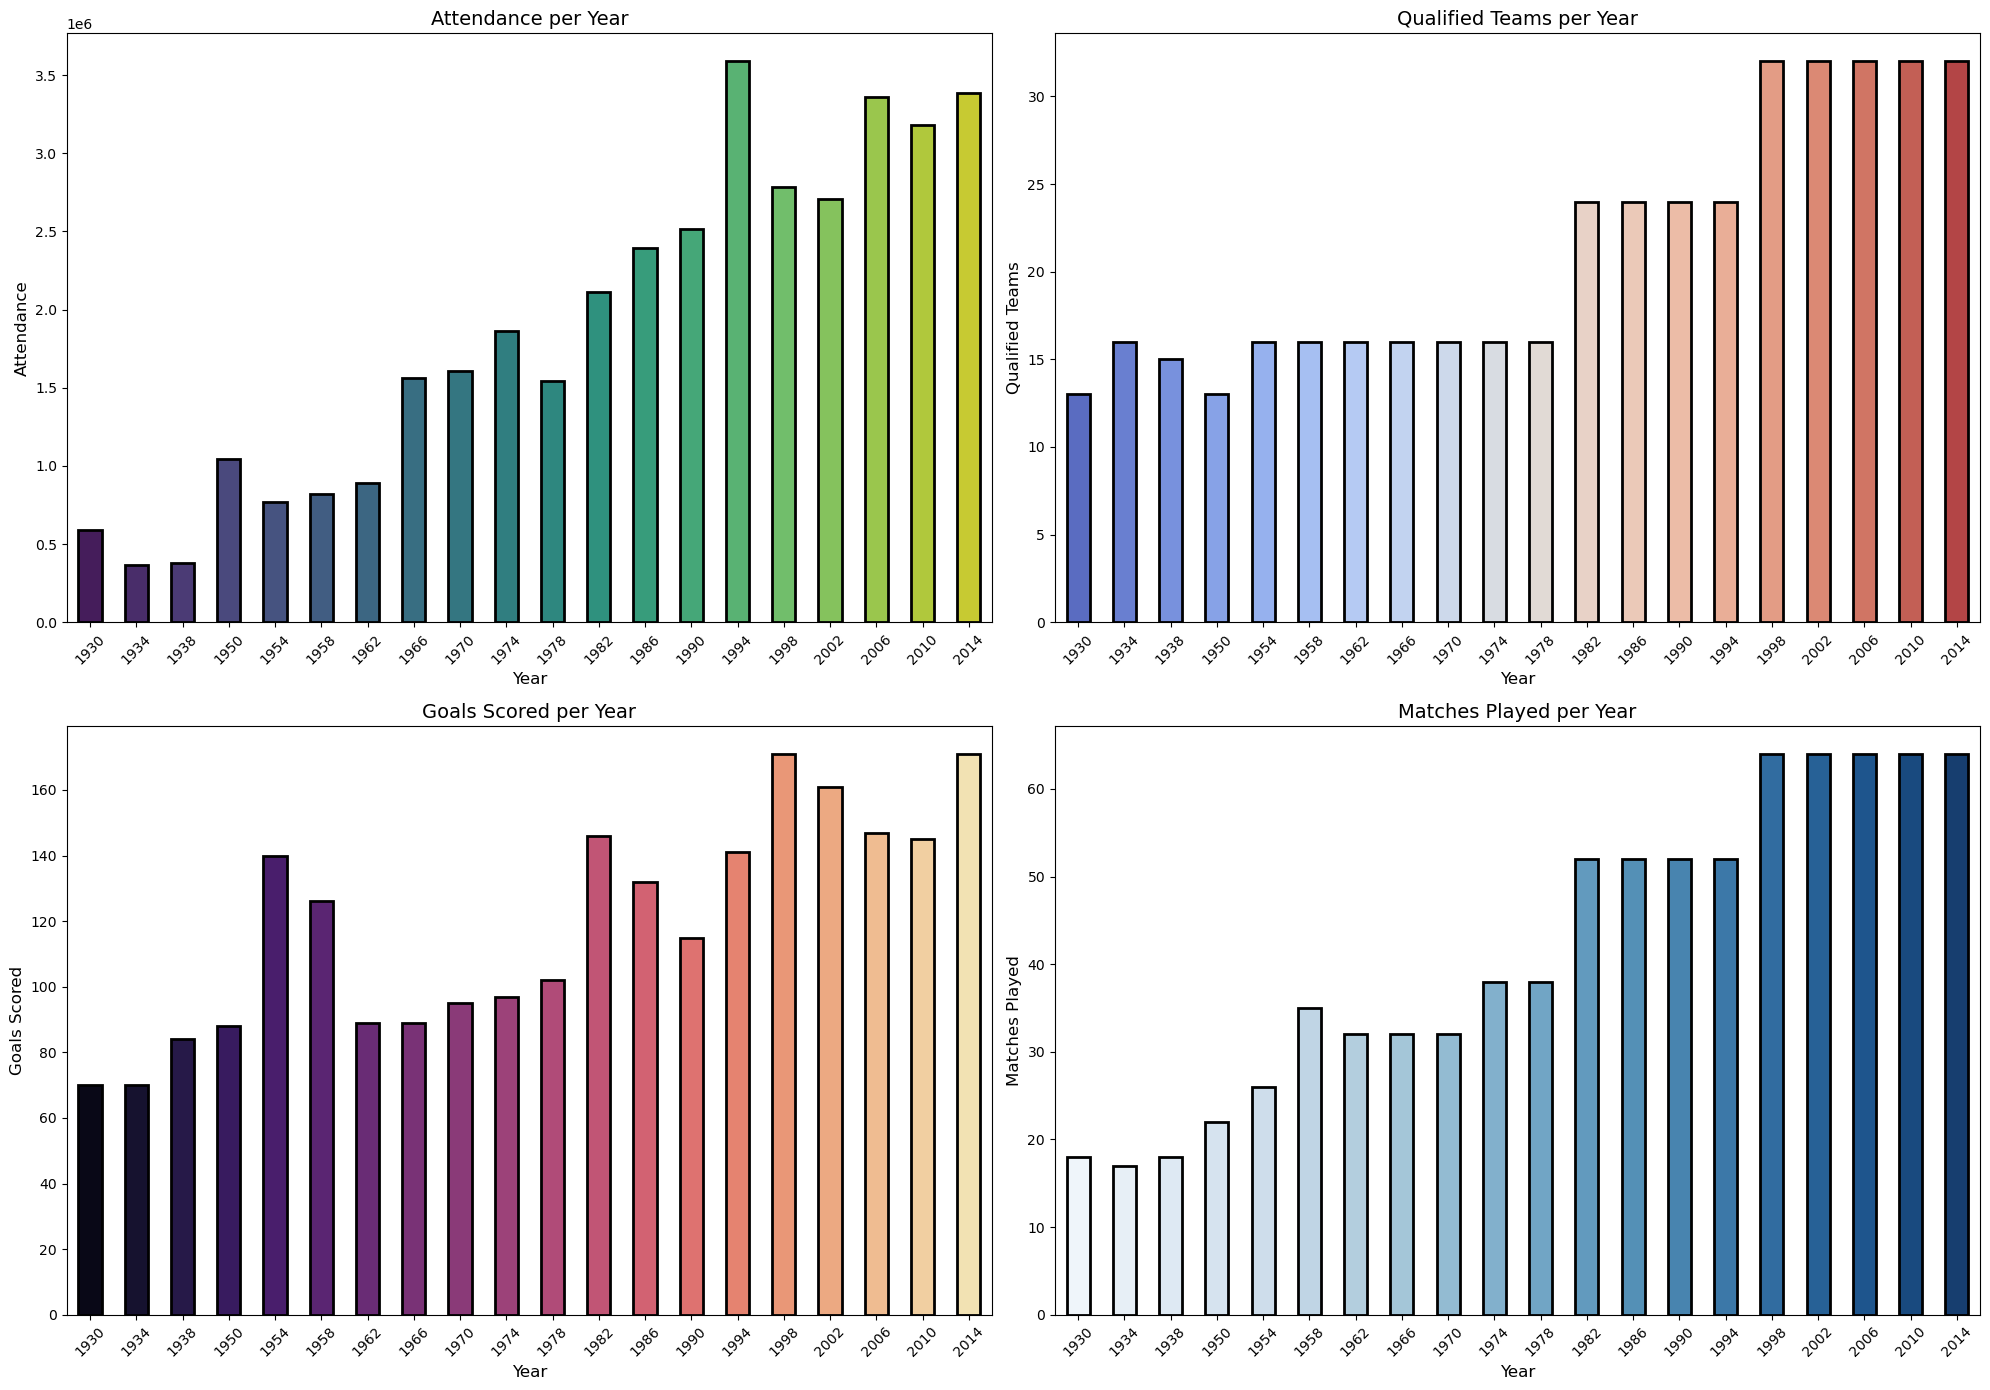

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# plot 1: Attendance per Year
sns.barplot(x=df['Year'].astype(str), y=df['Attendance'], ax=axes[0, 0], palette="viridis",width=0.5,edgecolor="black",linewidth=2)
axes[0, 0].set_title('Attendance per Year', fontsize=14)
axes[0, 0].set_xlabel('Year', fontsize=12)
axes[0, 0].set_ylabel('Attendance', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

#  plot 2: Qualified Teams per Year
sns.barplot(x=df['Year'].astype(str),y=df['QualifiedTeams'],ax=axes[0,1],palette='coolwarm',width=0.5,edgecolor="black",linewidth=2)
axes[0,1].set_title('Qualified Teams per Year',fontsize=14)
axes[0,1].set_xlabel('Year',fontsize=12)
axes[0,1].set_ylabel('Qualified Teams',fontsize=12)
axes[0,1].tick_params(axis='x',rotation=45)

# Plot 3: Goals Scored per Year
sns.barplot(x=df['Year'].astype(str),y=df['GoalsScored'],ax=axes[1,0],palette='magma',width=0.5,edgecolor="black",linewidth=2)
axes[1,0].set_title('Goals Scored per Year',fontsize=14)
axes[1,0].set_xlabel('Year',fontsize=12)
axes[1,0].set_ylabel('Goals Scored',fontsize=12)
axes[1,0].tick_params(axis='x',rotation=45)

# plot 4: Matches Played per Year
sns.barplot(x=df['Year'].astype(str),y=df['MatchesPlayed'],ax=axes[1,1],palette='Blues',width=0.5,edgecolor="black",linewidth=2)
axes[1,1].set_title('Matches Played per Year',fontsize=14)
axes[1,1].set_xlabel('Year',fontsize=12)
axes[1,1].set_ylabel('Matches Played',fontsize=12)
axes[1,1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

#  Trend of Goals per Match Over the Years

In [43]:
df.head(3)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700


In [44]:
df['Goals_per_Match'] = df['GoalsScored'] / df['MatchesPlayed']

In [45]:
df['Goals_per_Match']=df['Goals_per_Match'].round()

In [46]:
df['Goals_per_Match']=df['Goals_per_Match'].astype(int)

In [47]:
df.head(3)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance,Goals_per_Match
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549,4
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000,4
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700,5


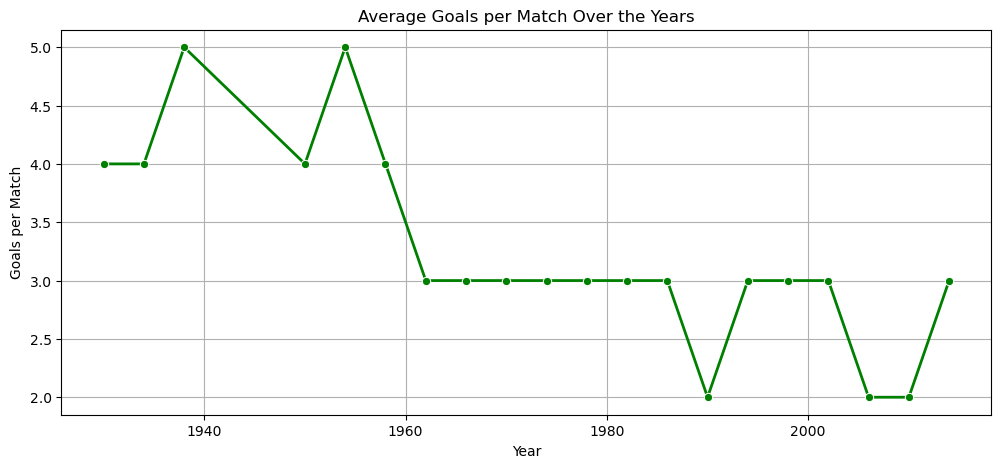

In [124]:
plt.figure(figsize=(12,5))
sns.lineplot(x=df['Year'],y=df['Goals_per_Match'],marker='o',color='g',linewidth=2)
plt.title('Average Goals per Match Over the Years')
plt.xlabel('Year')
plt.ylabel('Goals per Match')
plt.grid(True)
plt.show()

# Top Winning Countries (Most Titles)

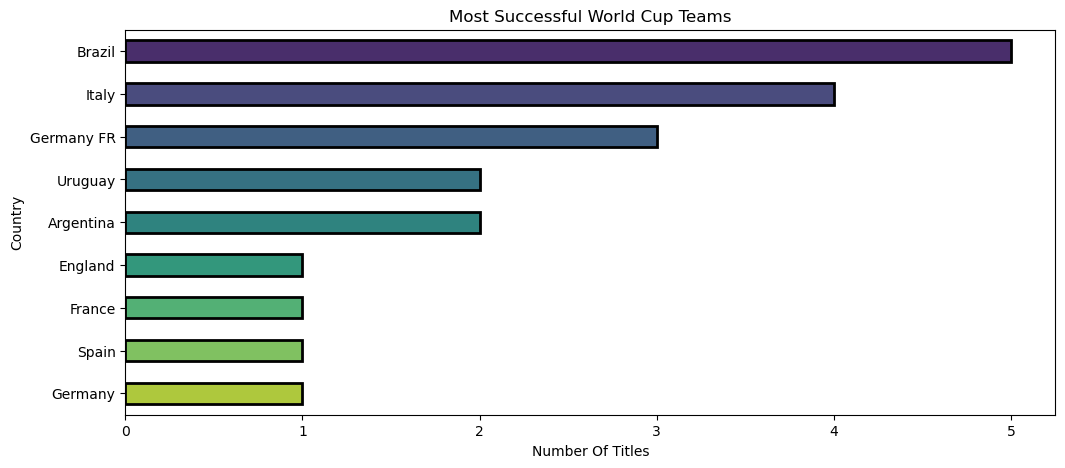

In [126]:
plt.figure(figsize=(12,5))
sns.countplot(y=df['Winner'],order=df['Winner'].value_counts().index,palette='viridis',width=0.5,edgecolor="black",linewidth=2)
plt.title('Most Successful World Cup Teams')
plt.xlabel('Number Of Titles')
plt.ylabel('Country')
plt.show()

# Growth in Attendance Over Time

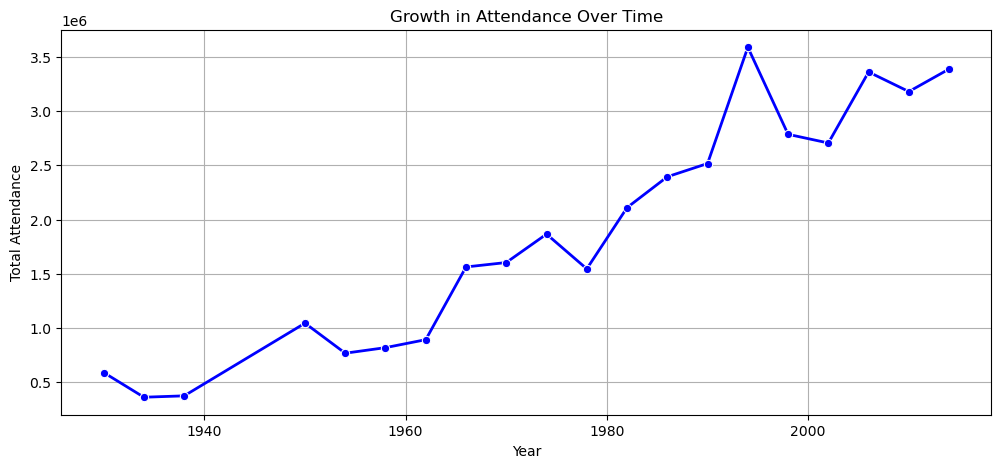

In [130]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=df['Year'], y=df['Attendance'], marker='o', color='b',linewidth=2)
plt.title('Growth in Attendance Over Time')
plt.xlabel('Year')
plt.ylabel('Total Attendance')
plt.grid(True)
plt.show()

# Correlation Heatmap

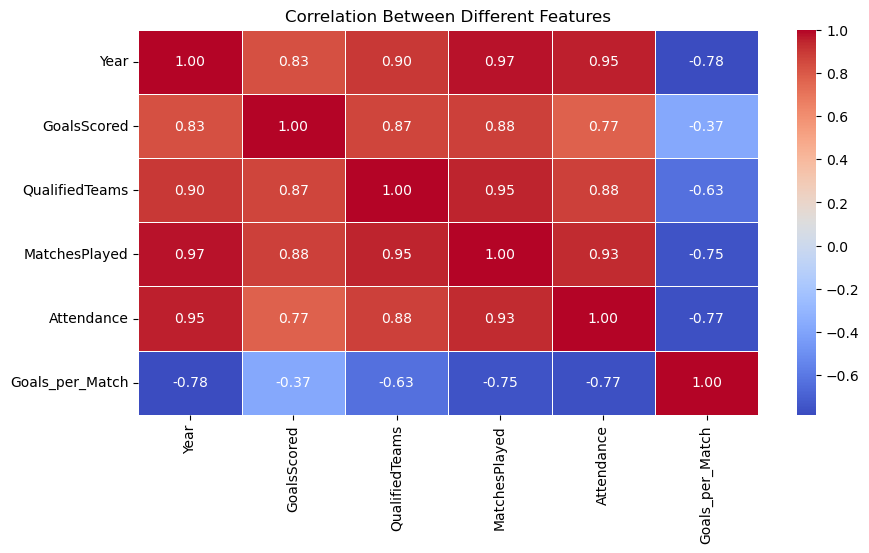

In [54]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5,)
plt.title('Correlation Between Different Features')
plt.show()

#  Relationship Between Goals & Matches Played

In [56]:
df.head(2)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance,Goals_per_Match
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549,4
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000,4


# Number of Goals per Country (for winning teams)

In [58]:
df.head(6)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance,Goals_per_Match
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549,4
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000,4
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700,5
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1045246,4
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768607,5
5,1958,Sweden,Brazil,Sweden,France,Germany FR,126,16,35,819810,4


In [59]:
df_goals = df.groupby('Country', as_index=False)['GoalsScored'].sum()
df_goals.columns = ['Country', 'TotalGoals']

In [60]:
df_goals

,Country,TotalGoals
0,Argentina,102
1,Brazil,259
2,Chile,89
3,England,89
4,France,255
5,Germany,244
6,Italy,185
7,Korea/Japan,161
8,Mexico,227
9,South Africa,145


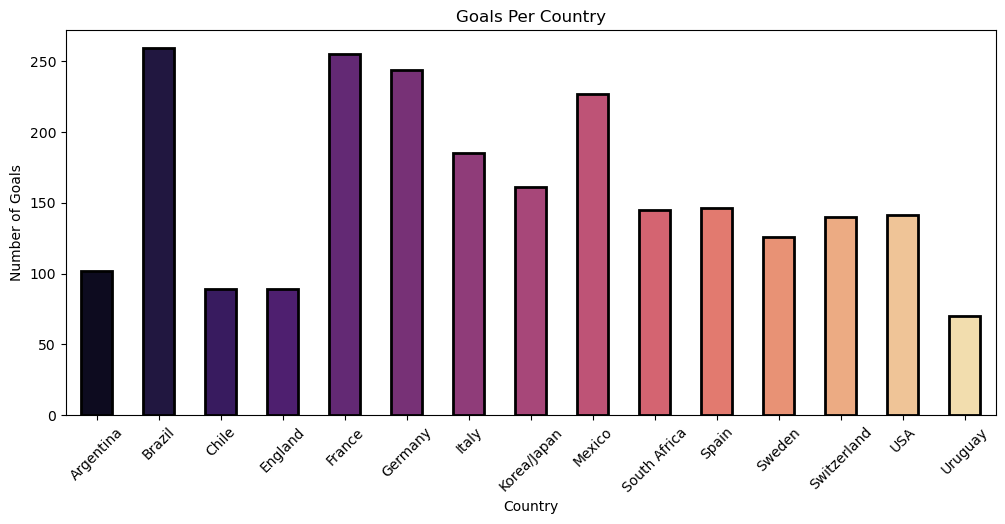

In [132]:
plt.figure(figsize=(12,5))
sns.barplot(x=df_goals['Country'],y=df_goals['TotalGoals'],palette="magma",width=0.5,edgecolor="black",linewidth=2)
plt.title('Goals Per Country')
plt.xlabel('Country')
plt.ylabel('Number of Goals')
plt.xticks(rotation=45)
plt.show()

# Match outcome by home and away temas


In [63]:
def get_labels(matches):
    if matches['Home Team Goals'] > matches['Away Team Goals']:
        return 'Home Team Win'
    if matches['Home Team Goals'] < matches['Away Team Goals']:
        return 'Away Team Win'
    return 'DRAW'

In [64]:
matches['outcome'] = matches.apply(lambda x: get_labels(x), axis=1)

In [65]:
matches.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,...,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials,outcome
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,...,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX,Home Team Win
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,...,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL,Home Team Win
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,...,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA,Home Team Win
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,...,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER,Home Team Win
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,...,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA,Home Team Win


In [66]:
mt = matches['outcome'].value_counts()
mt

outcome
Home Team Win    488
DRAW             190
Away Team Win    174
Name: count, dtype: int64

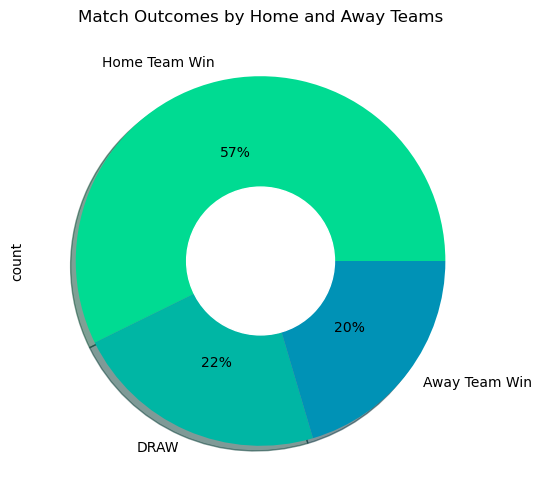

In [67]:
plt.figure(figsize=(6,6))
mt.plot.pie(autopct='%1.0f%%',colors=sns.color_palette('winter_r'),shadow=True)
c=plt.Circle((0,0),0.4,color='white')
plt.gca().add_artist(c)
plt.title('Match Outcomes by Home and Away Teams')
plt.show()